# 3/3 (v6) — Policy training driven purely by the time2success model

Follows `2_train_validate_v6.ipynb`.

**Fixes vs the previous version of this notebook:**

1. **`build_features` removed.** The v6 model was trained on the **raw 39-dim
   observation** — `1_collect_v6.ipynb` stores `feature_content: "raw 39-dim
   environment observation, nothing appended"`. The previous version built a
   49-dim vector and fed it to a 39-input model. That is a silent corruption:
   `load_state_dict` succeeds, the first `Linear` accepts the wrong width only
   if dims happen to line up, and otherwise every prediction is meaningless.
   Every reward in that run was suspect.
2. **Peg position stays in the observation.** `RemovePegPositionWrapper` is
   gone — the policy sees the same full 39-dim observation the environment
   emits, matching the dataset and every other notebook.
3. **`FEATURE_DIM = 49` → `OBS_DIM = 39`.**
4. **`callback = S`** — truncated line, fixed.

**New:** Section 5 inspects the reward before any training — per-step and
cumulative reward along an expert rollout, a failing rollout, and a random
policy, each with a video. That is the cheapest way to see whether the signal
points the right way before spending hours on it.

## 1. Setup

In [1]:
import numpy as np
import torch
import torch.nn as nn
import gymnasium as gym
import metaworld
import os, json, pickle, glob, time
import imageio
from stable_baselines3 import SAC
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor
from stable_baselines3.common.callbacks import BaseCallback
import matplotlib.pyplot as plt
from IPython.display import Video

TASK_NAME = "peg-insert-side-v3"
SUCCESS_KEY = "success"
OBS_DIM = 39          # raw env observation — what the v6 model was trained on

# Index positions, for diagnostics and plots only. Never used to reshape the
# model input: the model takes the raw observation unchanged.
HAND_POS_IDX = [0, 1, 2]
GRIPPER_IDX  = 3
PEG_POS_IDX  = [4, 5, 6]
GOAL_POS_IDX = [36, 37, 38]

def make_env(seed=0, render_mode=None):
    return gym.make("Meta-World/MT1", env_name=TASK_NAME, seed=seed, render_mode=render_mode, camera_name="corner2")

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


## Run configuration

In [2]:
# ============================================================
# RUN CONFIG — the only cell to edit between runs.
# Everything downstream derives from RUN_NAME, so checkpoints, TensorBoard
# logs and the saved VecNormalize stats always stay together.
# ============================================================
RUN_NAME = "v7_staged_abs_run1"

REWARD_MODE = "absolute"      # "absolute" -> r = -pred(s')   (time spent not-done costs)
                              # "difference" -> r = pred(s) - pred(s')  (telescopes; parking is free)

T2S_MODEL_DIR   = "./checkpoints/t2s_staged_v7"   # model trained WITH off-path data
PRED_CLIP_MAX   = 300.0                          # must be >= the censoring label (300)

TOTAL_TIMESTEPS = 1_000_000
N_ENVS          = 6
EVAL_FREQ       = 10_000
CKPT_FREQ       = 50_000
N_EVAL_EPISODES = 5

CKPT_DIR = f"./checkpoints/policy_{RUN_NAME}"
TB_DIR   = "./tb_logs/policy_runs"
VECNORM_PATH = os.path.join(CKPT_DIR, "vecnormalize.pkl")
FINAL_POLICY_PATH = os.path.join(CKPT_DIR, "policy_final")

os.makedirs(CKPT_DIR, exist_ok=True)
print(f"run: {RUN_NAME}\n  reward: {REWARD_MODE}\n  t2s: {T2S_MODEL_DIR}\n  ckpts: {CKPT_DIR}")

run: v7_staged_abs_run1
  reward: absolute
  t2s: ./checkpoints/t2s_staged_v7
  ckpts: ./checkpoints/policy_v7_staged_abs_run1


## 2. Load the frozen time2success model

Raw 39-dim observation in, predicted steps-remaining out. No feature engineering — the dataset had none.

In [4]:
class StagedTime2SuccessModel(nn.Module):
    def __init__(self, obs_dim, hidden=256, dropout=0.2, n_stages=3):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout),
        )
        self.t2s_head   = nn.Linear(hidden, 1)
        self.stage_head = nn.Linear(hidden, n_stages)

    def forward(self, x):
        h = self.encoder(x)
        return self.t2s_head(h).squeeze(-1), self.stage_head(h)

    def predict_t2s_only(self, x):
        return self.t2s_head(self.encoder(x)).squeeze(-1)

In [5]:
norm = np.load(os.path.join(T2S_MODEL_DIR, "normalization.npz"))
X_MEAN, X_STD = norm["X_mean"], norm["X_std"]
Y_MEAN, Y_STD = norm["y_mean"].item(), norm["y_std"].item()

assert X_MEAN.shape[0] == OBS_DIM, (
    f"normalization is {X_MEAN.shape[0]}-dim but OBS_DIM is {OBS_DIM} — "
    "wrong T2S_MODEL_DIR?")

t2s_model = StagedTime2SuccessModel(obs_dim=OBS_DIM).to(device)
t2s_model.load_state_dict(torch.load(os.path.join(T2S_MODEL_DIR, "model.pt")))
t2s_model.eval()
for p in t2s_model.parameters():
    p.requires_grad_(False)          # frozen — never trained during policy learning

@torch.no_grad()
def predict_t2s(obs, clip=True):
    x = torch.tensor((np.asarray(obs, dtype=np.float32) - X_MEAN) / X_STD,
                      dtype=torch.float32).unsqueeze(0).to(device)
    pred = t2s_model.predict_t2s_only(x).item() * Y_STD + Y_MEAN
    return float(np.clip(pred, 0.0, PRED_CLIP_MAX)) if clip else float(pred)

print(f"loaded {T2S_MODEL_DIR}, input dim {OBS_DIM}, clipped to [0, {PRED_CLIP_MAX}]")

loaded ./checkpoints/t2s_staged_v7, input dim 39, clipped to [0, 300.0]


In [33]:
peg_goal_dist = np.linalg.norm(obs[PEG_POS_IDX] - obs[GOAL_POS_IDX])

print("peg-to-goal distance:", peg_goal_dist)
print("raw T2S:", predict_t2s(obs, clip=False))
print("clipped T2S:", predict_t2s(obs, clip=True))

peg-to-goal distance: 0.39629767694709295
raw T2S: -11.584904929921322
clipped T2S: 0.0


## 3. The fixed scene — same `fixed_task.pkl` as notebooks 1 and 2

In [6]:
FIXED_TASK_PATH = "./data/state_space_datasetV7/fixed_task.pkl"
assert os.path.exists(FIXED_TASK_PATH), "run 1_collect_v7.ipynb first"

def find_wrapper(env, attr_name):
    w = env
    while not hasattr(w, attr_name):
        if not hasattr(w, "env"):
            raise AttributeError(f"no wrapper in the chain exposes {attr_name!r}")
        w = w.env
    return w

def make_fixed_scene_env(render_mode=None):
    env = make_env(seed=0, render_mode=render_mode)
    find_wrapper(env, "tasks").toggle_sample_tasks_on_reset(False)
    with open(FIXED_TASK_PATH, "rb") as f:
        fixed_task = pickle.load(f)
    env.unwrapped.set_task(fixed_task)
    return env

# confirm the scene really is fixed across resets
_e = make_fixed_scene_env()
_o1, _ = _e.reset(seed=1)
_o2, _ = _e.reset(seed=2)
_e.close()
assert np.allclose(_o1[PEG_POS_IDX + GOAL_POS_IDX], _o2[PEG_POS_IDX + GOAL_POS_IDX]), \
    "scene changed between resets — fixed_task did not take effect"
print("fixed scene confirmed — peg:", np.round(_o1[PEG_POS_IDX], 4),
      " goal:", np.round(_o1[GOAL_POS_IDX], 4))
print(f"observation dim: {_o1.shape[0]} (policy sees this in full — nothing stripped)")

fixed scene confirmed — peg: [0.1175 0.6784 0.03  ]  goal: [-0.2817  0.6375  0.1301]
observation dim: 39 (policy sees this in full — nothing stripped)


d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


## 4. Reward wrapper

`reward_t = predict_t2s(s_t) - predict_t2s(s_{t+1})` — the drop in predicted
steps-remaining. Positive when the model thinks the transition moved closer to
success. Replaces the environment reward entirely.

In [7]:
class Time2SuccessRewardWrapper(gym.Wrapper):
    """REWARD_MODE selects the form:

    "absolute"   r = -pred(s')       every step not-done costs. Expert -1,319
                                     vs failing -149,136 on the inspection.
    "difference" r = pred(s)-pred(s') telescopes to pred(first)-pred(last), so
                                     nothing between the endpoints counts and
                                     standing still is free. Both runs using
                                     this plateaued (at 41 and 15 predicted
                                     steps) for exactly that reason.
    """
    def __init__(self, env, reward_mode=None):
        super().__init__(env)
        self.reward_mode = reward_mode or REWARD_MODE
        assert self.reward_mode in ("absolute", "difference")
        self._last_pred = None

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self._last_pred = predict_t2s(obs)
        return obs, info

    def step(self, action):
        obs, _env_reward, terminated, truncated, info = self.env.step(action)  # env reward DISCARDED
        pred_now = predict_t2s(obs)
        if self.reward_mode == "absolute":
            reward = -pred_now
        else:
            reward = self._last_pred - pred_now
        self._last_pred = pred_now
        info["t2s_pred"] = pred_now
        return obs, reward, terminated, truncated, info


def make_policy_train_env():
    return Time2SuccessRewardWrapper(make_fixed_scene_env())

def make_policy_eval_env():
    """Raw env, real success flag, no reward shaping. Terminates on success so
    eval rollouts don't run the full horizon once the policy can solve it."""
    env = make_fixed_scene_env()
    find_wrapper(env, "toggle_terminate_on_success").toggle_terminate_on_success(True)
    return env

_env = make_policy_train_env()
_obs, _ = _env.reset()
_r = [_env.step(_env.action_space.sample())[1] for _ in range(20)]
_env.close()
print(f"policy observation shape: {_obs.shape} (expect ({OBS_DIM},))")
print(f"reward mode: {REWARD_MODE}")
print(f"reward over 20 random steps: min={min(_r):.2f}, max={max(_r):.2f}, mean={np.mean(_r):.2f}")
assert _obs.shape[0] == OBS_DIM

policy observation shape: (39,) (expect (39,))
reward mode: absolute
reward over 20 random steps: min=-300.00, max=-174.55, mean=-266.91


d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


## 5. Reward inspection — before any training

Three rollouts, each recorded to video with per-step and cumulative reward:

- **expert** (final checkpoint, deterministic) — what a correct trajectory earns
- **failing** (early checkpoint) — what a wrong-but-purposeful trajectory earns
- **random** — what flailing earns

The question these answer: does the reward separate these three? If the expert
does not clearly out-earn the other two, the signal cannot teach the task and
no amount of training time changes that.

In [10]:
def rollout_with_reward(policy, out_path, max_steps=500, deterministic=True, random_policy=False):
    """Runs a full rollout on the fixed scene, recording video, per-step reward,
    and the raw prediction. Uses the same reward wrapper the policy trains on."""
    env = Time2SuccessRewardWrapper(make_fixed_scene_env(render_mode="rgb_array"))
    obs, _ = env.reset()
    frames, rewards, preds = [], [], [predict_t2s(obs)]
    success_step = None
    for t in range(max_steps):
        frames.append(env.render())
        if random_policy:
            action = env.action_space.sample()
        else:
            action, _ = policy.predict(obs, deterministic=deterministic)
        obs, r, terminated, truncated, info = env.step(action)
        rewards.append(r)
        preds.append(info["t2s_pred"])
        if info.get(SUCCESS_KEY, 0) and success_step is None:
            success_step = t
        if terminated or truncated:
            break
    env.close()
    imageio.mimsave(out_path, frames, fps=20)
    return dict(rewards=np.array(rewards), preds=np.array(preds),
                success_step=success_step, n=len(frames), path=out_path)

In [11]:
checkpoint_paths = sorted(
    glob.glob("./checkpoints/peg_insert_side/sac_peg_insert_*.zip"),
    key=lambda p: int("".join(ch for ch in os.path.basename(p) if ch.isdigit()) or 0))
FINAL_CKPT = [p for p in checkpoint_paths if "final" in os.path.basename(p)][0]
EARLY_CKPT = checkpoint_paths[1]
print("expert :", os.path.basename(FINAL_CKPT))
print("failing:", os.path.basename(EARLY_CKPT))

expert  = rollout_with_reward(SAC.load(FINAL_CKPT), "reward_check_expert.mp4")
failing = rollout_with_reward(SAC.load(EARLY_CKPT), "reward_check_failing.mp4")
randoms = rollout_with_reward(None, "reward_check_random.mp4", random_policy=True)

for name, r in [("expert", expert), ("failing", failing), ("random", randoms)]:
    print(f"{name:8s}: {r['n']:3d} frames, success={r['success_step']}, "
          f"total reward={r['rewards'].sum():+8.2f}, "
          f"mean/step={r['rewards'].mean():+.4f}, "
          f"|r| max={np.abs(r['rewards']).max():.2f}")

expert : sac_peg_insert_final.zip
failing: sac_peg_insert_100000.zip


d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


expert  : 500 frames, success=48, total reward=-2554.09, mean/step=-5.1082, |r| max=161.17
failing : 500 frames, success=None, total reward=-149438.70, mean/step=-298.8774, |r| max=300.00
random  : 500 frames, success=None, total reward=-149336.19, mean/step=-298.6724, |r| max=300.00


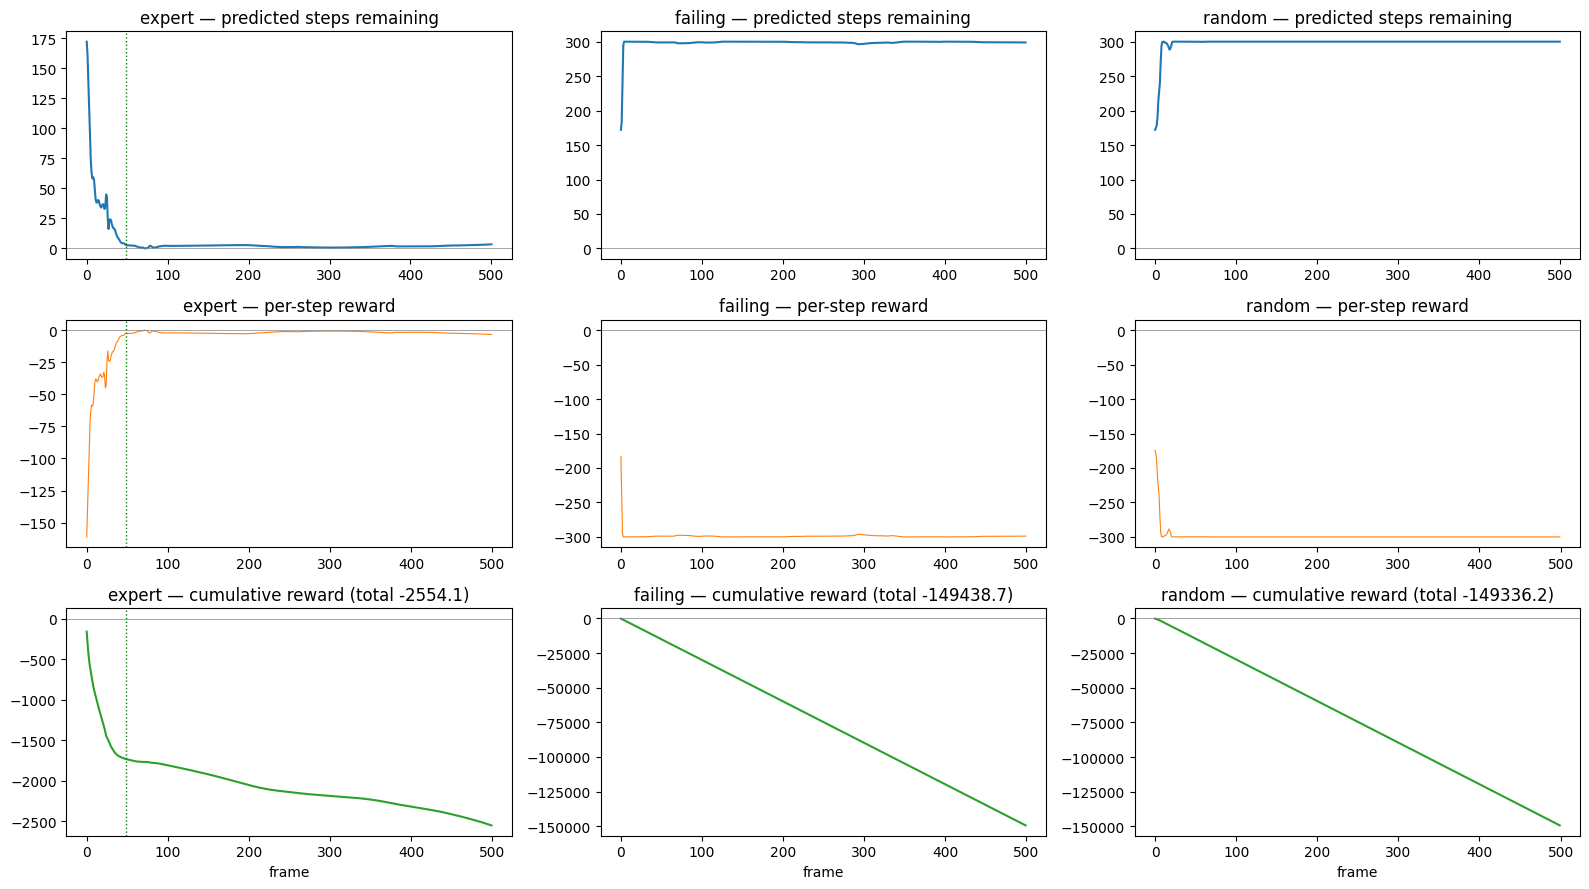

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(16, 9))
for col, (name, r) in enumerate([("expert", expert), ("failing", failing), ("random", randoms)]):
    axes[0, col].plot(r["preds"], color="tab:blue")
    axes[0, col].set_title(f"{name} — predicted steps remaining")
    axes[0, col].axhline(0, color="gray", lw=0.5)

    axes[1, col].plot(r["rewards"], color="tab:orange", lw=0.8)
    axes[1, col].set_title(f"{name} — per-step reward")
    axes[1, col].axhline(0, color="gray", lw=0.5)

    axes[2, col].plot(np.cumsum(r["rewards"]), color="tab:green")
    axes[2, col].set_title(f"{name} — cumulative reward (total {r['rewards'].sum():+.1f})")
    axes[2, col].axhline(0, color="gray", lw=0.5)
    axes[2, col].set_xlabel("frame")

    if r["success_step"] is not None:
        for row in range(3):
            axes[row, col].axvline(r["success_step"], color="green", ls=":", lw=1)

plt.tight_layout(); plt.show()

**How to read this.**

The cumulative-reward row is the decisive one — it is what SAC maximizes.

- Expert clearly highest, random lowest → the signal separates good from bad
  behaviour, and training is worth attempting.
- Expert not clearly highest → the reward does not prefer the correct motion,
  and training will optimize toward whatever *does* score highest instead.
- Note the telescoping property: over a whole episode the per-step differences
  sum to `predict_t2s(s_0) - predict_t2s(s_final)`. An expert starting near 60
  and ending at 0 should total roughly +60. A rollout that ends where it
  started totals roughly 0 regardless of what happened in between.

In [13]:
Video(expert["path"], embed=True)

In [ ]:
Video(failing["path"], embed=True)

In [ ]:
Video(randoms["path"], embed=True)

## 6. Vectorized training env + SAC

In [14]:
from stable_baselines3.common.vec_env import VecNormalize

train_env = VecMonitor(DummyVecEnv([make_policy_train_env for _ in range(N_ENVS)]))
train_env = VecNormalize(train_env, norm_obs=False, norm_reward=True, clip_reward=10.0)

# eval_env was commented out in the previous version, so the smoke-test and
# callback cells raised NameError. It must NOT be VecNormalize-wrapped — eval
# reports the real success flag on the raw env.
eval_env = make_policy_eval_env()

print("train env observation_space:", train_env.observation_space)
print("norm_obs=False (policy and t2s model must see identical observations)")
print("norm_reward=True — essential with the absolute form, where raw rewards reach -300")

model = SAC(
    policy="MlpPolicy",
    env=train_env,
    learning_rate=3e-4,
    buffer_size=300_000,
    batch_size=256,
    tau=0.005,
    gamma=0.99,
    ent_coef="auto",
    policy_kwargs=dict(net_arch=[400, 400]),
    tensorboard_log=TB_DIR,
    verbose=0,
    seed=0,
)

train env observation_space: Box([-0.525   0.348  -0.0525 -1.        -inf    -inf    -inf    -inf    -inf
    -inf    -inf    -inf    -inf    -inf    -inf    -inf    -inf    -inf
 -0.525   0.348  -0.0525 -1.        -inf    -inf    -inf    -inf    -inf
    -inf    -inf    -inf    -inf    -inf    -inf    -inf    -inf    -inf
  0.      0.      0.    ], [0.525 1.025 0.7   1.      inf   inf   inf   inf   inf   inf   inf   inf
   inf   inf   inf   inf   inf   inf 0.525 1.025 0.7   1.      inf   inf
   inf   inf   inf   inf   inf   inf   inf   inf   inf   inf   inf   inf
 0.    0.    0.   ], (39,), float64)
norm_obs=False (policy and t2s model must see identical observations)
norm_reward=True — essential with the absolute form, where raw rewards reach -300


In [15]:
train_env.save(VECNORM_PATH)

In [16]:
class SuccessCallback(BaseCallback):
    def __init__(self, eval_env, eval_freq=EVAL_FREQ, n_eval_episodes=N_EVAL_EPISODES,
                 ckpt_dir=CKPT_DIR, ckpt_freq=CKPT_FREQ, verbose=1):
        super().__init__(verbose)
        self.eval_env = eval_env
        self.eval_freq = eval_freq
        self.n_eval_episodes = n_eval_episodes
        self.ckpt_dir = ckpt_dir
        self.ckpt_freq = ckpt_freq
        os.makedirs(ckpt_dir, exist_ok=True)
        self.history = []
        self.best_sr = -1.0

    def _run_eval_episode(self):
        obs, _ = self.eval_env.reset()
        for t in range(500):
            action, _ = self.model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = self.eval_env.step(action)
            if info.get(SUCCESS_KEY, 0):
                return t
            if terminated or truncated:
                break
        return None

    def _on_step(self) -> bool:
        if self.num_timesteps % self.ckpt_freq < self.training_env.num_envs:
            self.model.save(os.path.join(self.ckpt_dir, f"policy_{self.num_timesteps}.zip"))

        if self.num_timesteps % self.eval_freq < self.training_env.num_envs:
            steps = [self._run_eval_episode() for _ in range(self.n_eval_episodes)]
            sr = sum(s is not None for s in steps) / self.n_eval_episodes
            times = [s for s in steps if s is not None]
            mt = float(np.mean(times)) if times else None
            self.logger.record("eval/success_rate", sr)
            if mt is not None:
                self.logger.record("eval/mean_time_to_success", mt)
            self.history.append(dict(step=self.num_timesteps, success_rate=sr,
                                       mean_time_to_success=mt, timestamp=time.time()))
            with open(os.path.join(self.ckpt_dir, "eval_history.json"), "w") as f:
                json.dump(self.history, f, indent=2)
            if sr > self.best_sr:          # keep whatever peaked, even briefly
                self.best_sr = sr
                self.model.save(os.path.join(self.ckpt_dir, f"best_sr{sr:.2f}_{self.num_timesteps}.zip"))
            if self.verbose:
                print(f"[{time.strftime('%H:%M:%S')}] eval @ {self.num_timesteps}: "
                      f"success_rate={sr:.2f} mean_t2s={mt}")
        return True

callback = SuccessCallback(eval_env=eval_env)

## 7. Smoke test

In [92]:
_t0 = time.time()
model.learn(total_timesteps=3_000,
            callback=SuccessCallback(eval_env=eval_env, eval_freq=1_000, ckpt_freq=1_000),
            tb_log_name=f"{RUN_NAME}_smoke")
print(f"\nsmoke test: 3,000 steps in {time.time()-_t0:.0f}s")
print("check rollout/ep_len_mean above — should be 500 (nothing truncates training episodes)")
print(f"ep_rew_mean will be a large negative under the absolute form; "
      f"expert baseline for reference is about -1,319 per episode")

[21:48:14] eval @ 1002: success_rate=0.00 mean_t2s=None
[21:48:20] eval @ 2004: success_rate=0.00 mean_t2s=None
[21:48:26] eval @ 3000: success_rate=0.00 mean_t2s=None

smoke test: 3,000 steps in 17s
check rollout/ep_len_mean above — should be 500 (nothing truncates training episodes)
ep_rew_mean will be a large negative under the absolute form; expert baseline for reference is about -1,319 per episode


## 8. Full run

In [17]:
print(f"[{time.strftime('%H:%M:%S')}] starting learn() — {TOTAL_TIMESTEPS:,} steps, run={RUN_NAME}")
model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callback,
            tb_log_name=RUN_NAME, reset_num_timesteps=False)
print(f"[{time.strftime('%H:%M:%S')}] learn() RETURNED")

model.save(FINAL_POLICY_PATH)
train_env.save(VECNORM_PATH)          # reward-normalization stats — needed to resume
print(f"[{time.strftime('%H:%M:%S')}] SAVED policy + vecnormalize — safe to interrupt from here")

print(f"[{time.strftime('%H:%M:%S')}] CELL COMPLETE "
      f"(envs left open so the resume cell below can continue this run)")

[20:52:28] starting learn() — 1,000,000 steps, run=v7_staged_abs_run1
[20:53:05] eval @ 10002: success_rate=0.00 mean_t2s=None
[20:53:40] eval @ 20004: success_rate=0.00 mean_t2s=None
[20:54:16] eval @ 30000: success_rate=0.00 mean_t2s=None
[20:54:51] eval @ 40002: success_rate=0.00 mean_t2s=None
[20:55:26] eval @ 50004: success_rate=0.00 mean_t2s=None
[20:56:01] eval @ 60000: success_rate=0.00 mean_t2s=None
[20:56:35] eval @ 70002: success_rate=0.00 mean_t2s=None
[20:57:10] eval @ 80004: success_rate=0.00 mean_t2s=None
[20:57:44] eval @ 90000: success_rate=0.00 mean_t2s=None
[20:58:20] eval @ 100002: success_rate=0.00 mean_t2s=None
[20:58:55] eval @ 110004: success_rate=0.00 mean_t2s=None
[20:59:30] eval @ 120000: success_rate=0.00 mean_t2s=None
[21:00:05] eval @ 130002: success_rate=0.00 mean_t2s=None
[21:00:40] eval @ 140004: success_rate=0.00 mean_t2s=None
[21:01:14] eval @ 150000: success_rate=0.00 mean_t2s=None
[21:01:49] eval @ 160002: success_rate=0.00 mean_t2s=None
[21:02:26] 

## 9. Did it learn anything?

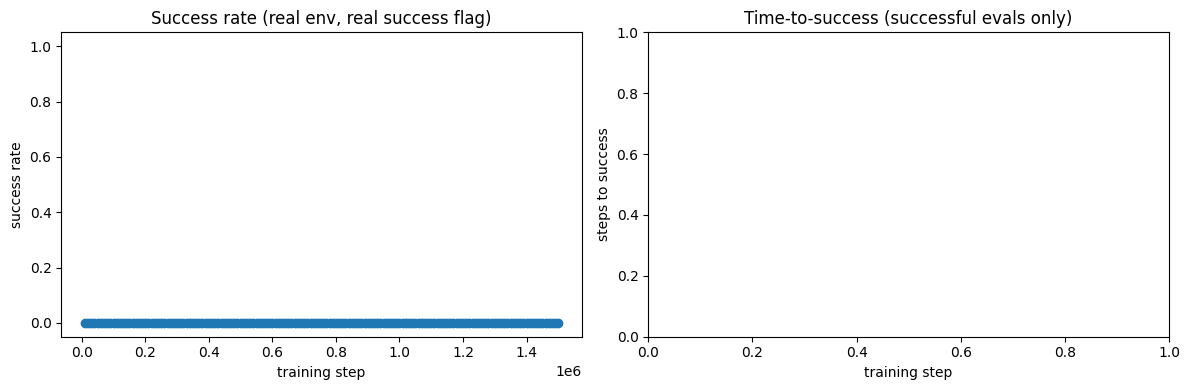

final: 0.00 | best: 0.00 at step 10002


In [28]:
with open(CKPT_DIR + "/eval_history.json") as f:
    history = json.load(f)

steps = [h["step"] for h in history]
srs = [h["success_rate"] for h in history]
mts = [h["mean_time_to_success"] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(steps, srs, marker="o")
axes[0].set_xlabel("training step"); axes[0].set_ylabel("success rate")
axes[0].set_title("Success rate (real env, real success flag)")
axes[0].set_ylim(-0.05, 1.05)

valid = [(s, m) for s, m in zip(steps, mts) if m is not None]
if valid:
    vs, vm = zip(*valid)
    axes[1].plot(vs, vm, marker="o", color="tab:orange")
axes[1].set_xlabel("training step"); axes[1].set_ylabel("steps to success")
axes[1].set_title("Time-to-success (successful evals only)")
plt.tight_layout(); plt.show()

print(f"final: {srs[-1]:.2f} | best: {max(srs):.2f} at step {steps[srs.index(max(srs))]}")

## 10. Final policy rollout — video + prediction trace

In [31]:
expert = rollout_with_reward(SAC.load(FINAL_CKPT), "reward_check_expert.mp4")
expert_pol = SAC.load(FINAL_CKPT)

500 frames, success=None, total reward=-2522.20
compare against expert total: -2554.09


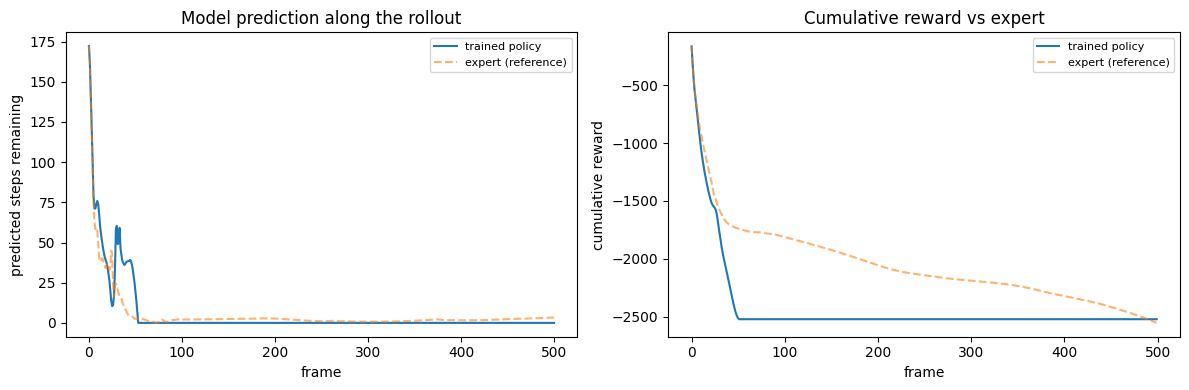

In [32]:
final_policy = SAC.load(FINAL_POLICY_PATH)
result = rollout_with_reward(final_policy, "validation_policy_v_timediff.mp4")

print(f"{result['n']} frames, success={result['success_step']}, "
      f"total reward={result['rewards'].sum():+.2f}")
print(f"compare against expert total: {expert['rewards'].sum():+.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(result["preds"], label="trained policy")
axes[0].plot(expert["preds"], "--", alpha=0.6, label="expert (reference)")
axes[0].set_xlabel("frame"); axes[0].set_ylabel("predicted steps remaining")
axes[0].legend(fontsize=8); axes[0].set_title("Model prediction along the rollout")

axes[1].plot(np.cumsum(result["rewards"]), label="trained policy")
axes[1].plot(np.cumsum(expert["rewards"]), "--", alpha=0.6, label="expert (reference)")
axes[1].set_xlabel("frame"); axes[1].set_ylabel("cumulative reward")
axes[1].legend(fontsize=8); axes[1].set_title("Cumulative reward vs expert")
plt.tight_layout(); plt.show()

In [ ]:
Video("validation_policy_v6_timediff.mp4", embed=True)

Grasp reward check

In [21]:
env = make_policy_train_env()
obs, _ = env.reset()
peg_start = obs[PEG_POS_IDX].copy()
peg_path, gripper_vals, min_hand_peg = 0.0, [], np.inf
last = peg_start.copy()
policy = final_policy

for t in range(500):
    a, _ = policy.predict(obs, deterministic=True)
    obs, r, term, trunc, info = env.step(a)
    peg_path += np.linalg.norm(obs[PEG_POS_IDX] - last)
    last = obs[PEG_POS_IDX].copy()
    gripper_vals.append(obs[GRIPPER_IDX])
    min_hand_peg = min(min_hand_peg, np.linalg.norm(obs[HAND_POS_IDX] - obs[PEG_POS_IDX]))
    if term or trunc: break
env.close()

print(f"peg net displacement: {np.linalg.norm(last - peg_start):.4f} m")
print(f"peg path length:      {peg_path:.4f} m")
print(f"closest hand-to-peg:  {min_hand_peg:.4f} m  (expert grasps around 0.03-0.04)")
print(f"gripper range:        {min(gripper_vals):.3f} to {max(gripper_vals):.3f}  (1.0 open, ~0.28 closed)")

peg net displacement: 0.2918 m
peg path length:      0.3425 m
closest hand-to-peg:  0.0338 m  (expert grasps around 0.03-0.04)
gripper range:        0.327 to 1.000  (1.0 open, ~0.28 closed)


In [22]:
expert = SAC.load(FINAL_CKPT)
env = make_fixed_scene_env()
obs, _ = env.reset()
traj = []
for t in range(120):
    traj.append(obs.copy())
    a, _ = expert.predict(obs, deterministic=True)
    obs, *_ = env.step(a)
env.close()

grip = np.array([o[GRIPPER_IDX] for o in traj])
grasp_frame = int(np.argmax(grip < 0.6))
for k in [-10, -5, -2, 0, 2, 5, 10]:
    i = grasp_frame + k
    if 0 <= i < len(traj):
        print(f"frame {i:3d} (grasp{k:+d}): pred={predict_t2s(traj[i]):6.2f}  "
              f"gripper={grip[i]:.3f}")

frame  16 (grasp-10): pred= 36.69  gripper=1.000
frame  21 (grasp-5): pred= 36.52  gripper=0.876
frame  24 (grasp-2): pred= 44.95  gripper=0.714
frame  26 (grasp+0): pred= 24.41  gripper=0.587
frame  28 (grasp+2): pred= 23.77  gripper=0.448
frame  31 (grasp+5): pred= 20.17  gripper=0.294
frame  36 (grasp+10): pred= 12.77  gripper=0.290


In [108]:
acts = []
obs, _ = env.reset()
for t in range(200):
    a, _ = policy.predict(obs, deterministic=True)
    acts.append(a.copy())
    obs, *_ = env.step(a)
acts = np.array(acts)
print("action mean per dim:", np.round(acts.mean(axis=0), 3))
print("action std per dim: ", np.round(acts.std(axis=0), 3))

action mean per dim: [-0.015  0.038 -0.252 -0.415]
action std per dim:  [0.358 0.492 0.387 0.309]


In [110]:
expert = SAC.load(FINAL_CKPT)
env = make_fixed_scene_env()
obs, _ = env.reset()
rows = []
for t in range(80):
    a, _ = expert.predict(obs, deterministic=True)
    rows.append((t, a[3], obs[GRIPPER_IDX]))
    obs, *_ = env.step(a)
env.close()
for t, a3, g in rows[::5]:
    print(f"frame {t:3d}: action[3]={a3:+.3f}  obs[3]={g:.3f}")

frame   0: action[3]=-0.816  obs[3]=1.000
frame   5: action[3]=-0.786  obs[3]=1.000
frame  10: action[3]=-0.512  obs[3]=1.000
frame  15: action[3]=+0.099  obs[3]=1.000
frame  20: action[3]=+0.998  obs[3]=0.918
frame  25: action[3]=+0.997  obs[3]=0.652
frame  30: action[3]=+0.984  obs[3]=0.326
frame  35: action[3]=+0.969  obs[3]=0.285
frame  40: action[3]=+0.848  obs[3]=0.297
frame  45: action[3]=+0.893  obs[3]=0.299
frame  50: action[3]=+0.884  obs[3]=0.299
frame  55: action[3]=+0.808  obs[3]=0.299
frame  60: action[3]=+0.663  obs[3]=0.300
frame  65: action[3]=+0.630  obs[3]=0.313
frame  70: action[3]=+0.365  obs[3]=0.368
frame  75: action[3]=+0.284  obs[3]=0.379


In [25]:
env = make_fixed_scene_env()
obs, _ = env.reset()
for t in range(200):
    a, _ = final_policy.predict(obs, deterministic=True)
    obs, *_ = env.step(a)
env.close()
print("peg z:", obs[PEG_POS_IDX][2], " pred:", predict_t2s(obs))

peg z: 0.024852409588876738  pred: 0.0


## 11. Training-curve diagnostic

available tags: ['rollout/ep_len_mean', 'rollout/ep_rew_mean', 'time/fps', 'train/actor_loss', 'train/critic_loss', 'train/ent_coef', 'train/ent_coef_loss', 'train/learning_rate', 'eval/success_rate']


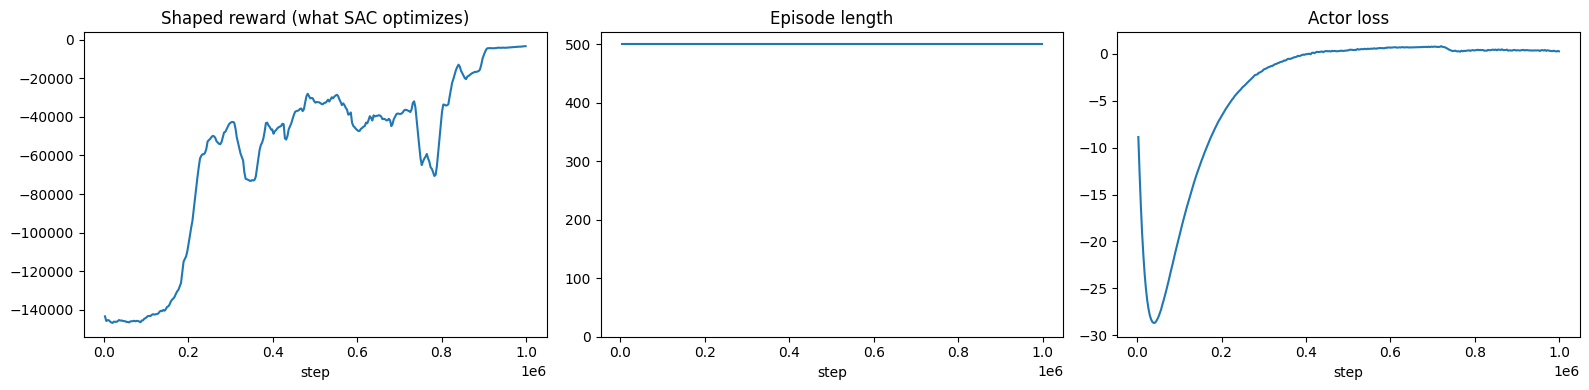

In [23]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

run_dirs = sorted(glob.glob(os.path.join(TB_DIR, f"{RUN_NAME}*")))
assert run_dirs, f"no TensorBoard runs matching {RUN_NAME} in {TB_DIR}"
ea = EventAccumulator(run_dirs[-1]); ea.Reload()
print("available tags:", ea.Tags()["scalars"])

def scal(tag):
    ev = ea.Scalars(tag)
    return [p.step for p in ev], [p.value for p in ev]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, tag, title in [
    (axes[0], "rollout/ep_rew_mean", "Shaped reward (what SAC optimizes)"),
    (axes[1], "rollout/ep_len_mean", "Episode length"),
    (axes[2], "train/actor_loss", "Actor loss"),
]:
    try:
        s, v = scal(tag)
        ax.plot(s, v)
    except KeyError:
        ax.text(0.5, 0.5, f"{tag}\nnot logged", ha="center", va="center")
    ax.set_title(title); ax.set_xlabel("step")
axes[1].set_ylim(0, 520)
plt.tight_layout(); plt.show()

**Reading the outcome.**

`eval/success_rate` is the only quantity measured against ground truth —
everything else describes the model's own opinion of the policy.

If shaped reward climbs while success stays at 0, the policy is optimizing the
reward successfully and the reward is not the task. Compare the final policy's
cumulative reward against the expert's in Section 10: if the trained policy
*out-earns* the expert without succeeding, that is reward hacking, and it
localizes the problem to the model's behaviour off the demonstration manifold
rather than to anything about SAC or the hyperparameters.

## Continue training

Run this to add more steps to the **same** run — `model` and `train_env` are
still live in the kernel, so this picks up exactly where the last cell stopped.
`reset_num_timesteps=False` keeps the step counter and TensorBoard curve
continuous.

If the kernel was restarted, run the "resume from disk" cell below instead.

In [26]:
ADDITIONAL_TIMESTEPS = 500_000

print(f"[{time.strftime('%H:%M:%S')}] continuing {RUN_NAME} from step {model.num_timesteps:,} "
      f"for {ADDITIONAL_TIMESTEPS:,} more")
model.learn(total_timesteps=ADDITIONAL_TIMESTEPS, callback=callback,
            tb_log_name=RUN_NAME, reset_num_timesteps=False)

model.save(FINAL_POLICY_PATH)
train_env.save(VECNORM_PATH)
print(f"[{time.strftime('%H:%M:%S')}] now at step {model.num_timesteps:,}, saved")

[21:58:12] continuing v7_staged_abs_run1 from step 1,000,002 for 500,000 more
[21:58:51] eval @ 1010004: success_rate=0.00 mean_t2s=None
[21:59:28] eval @ 1020000: success_rate=0.00 mean_t2s=None
[22:00:07] eval @ 1030002: success_rate=0.00 mean_t2s=None
[22:00:46] eval @ 1040004: success_rate=0.00 mean_t2s=None
[22:01:23] eval @ 1050000: success_rate=0.00 mean_t2s=None
[22:02:00] eval @ 1060002: success_rate=0.00 mean_t2s=None
[22:02:39] eval @ 1070004: success_rate=0.00 mean_t2s=None
[22:03:15] eval @ 1080000: success_rate=0.00 mean_t2s=None
[22:03:53] eval @ 1090002: success_rate=0.00 mean_t2s=None
[22:04:31] eval @ 1100004: success_rate=0.00 mean_t2s=None
[22:05:08] eval @ 1110000: success_rate=0.00 mean_t2s=None
[22:05:45] eval @ 1120002: success_rate=0.00 mean_t2s=None
[22:06:22] eval @ 1130004: success_rate=0.00 mean_t2s=None
[22:06:59] eval @ 1140000: success_rate=0.00 mean_t2s=None
[22:07:36] eval @ 1150002: success_rate=0.00 mean_t2s=None
[22:08:13] eval @ 1160004: success_ra

### Resume from disk (after a kernel restart)

Rebuilds the env, reloads the `VecNormalize` statistics, and attaches the saved
policy. Skipping the `VecNormalize.load` would restart the running reward
statistics from scratch, which changes the effective reward scale mid-run.

In [ ]:
from stable_baselines3.common.vec_env import VecNormalize

train_env = VecMonitor(DummyVecEnv([make_policy_train_env for _ in range(N_ENVS)]))
train_env = VecNormalize.load(VECNORM_PATH, train_env)
train_env.training = True
train_env.norm_reward = True

eval_env = make_policy_eval_env()
model = SAC.load(FINAL_POLICY_PATH, env=train_env, tensorboard_log=TB_DIR)
callback = SuccessCallback(eval_env=eval_env)

print(f"resumed {RUN_NAME} at step {model.num_timesteps:,}")
print(f"reward running std: {np.sqrt(train_env.ret_rms.var):.1f} "
      f"(if this is near 1, normalization is not doing much)")